# SimpleNews Refactored Control Panel (S0–S6)

This notebook is **display-first**. It is meant to be easy to scan during review and report writing.

It does **not** train models or rebuild systems. Instead, it helps you:
- verify that the expected output files exist
- inspect a **small, essential EDA snapshot**
- review the main S0–S6 result tables
- display the report plots
- preview the combined output file


## Notebook map

**0. Project status**  
Check that the key files for the refactored pipeline exist.

**1. Essential EDA snapshot**  
A compact dataset overview only: article/reference lengths, compression ratio, and lightweight article fact-density stats.

**2. Main metric summary**  
Open the refactored system-level summary table.

**3. Compact main-results table**  
Show the report-friendly compact comparison table.

**4. Document counts by system**  
Confirm how many documents are present for each system.

**5. Generated plots**  
Display the saved report figures.

**6. Combined output preview**  
Preview the first rows of the merged S0–S6 output file.



In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import re
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path('.').resolve()
if not (ROOT / 'outputs').exists() and (ROOT.parent / 'outputs').exists():
    ROOT = ROOT.parent

OUTPUTS = ROOT / 'outputs'
TABLES = OUTPUTS / 'tables'
FIGURES = OUTPUTS / 'figures'
CACHE = OUTPUTS / 'cache'
DATA = ROOT / 'data'

print('Project root:', ROOT)
print('Outputs dir:', OUTPUTS)
print('Tables dir exists:', TABLES.exists())
print('Figures dir exists:', FIGURES.exists())
print('Data dir exists:', DATA.exists())

Project root: /Users/gm/Desktop/Final S0 to S6/simplenews_s0_s6
Outputs dir: /Users/gm/Desktop/Final S0 to S6/simplenews_s0_s6/outputs
Tables dir exists: True
Figures dir exists: True
Data dir exists: False


## 0. Project status

In [2]:
status_items = [
    ('data/test.csv', DATA / 'test.csv'),
    ('outputs/cache/test_preprocess_summary.csv', CACHE / 'test_preprocess_summary.csv'),
    ('outputs/system_runs/test_S6.csv', OUTPUTS / 'system_runs' / 'test_S6.csv'),
    ('outputs/test_all_systems_combined.csv', OUTPUTS / 'test_all_systems_combined.csv'),
    ('outputs/tables/test_metric_summary_refactored.csv', TABLES / 'test_metric_summary_refactored.csv'),
    ('outputs/tables/test_main_results_compact.csv', TABLES / 'test_main_results_compact.csv'),
    ('outputs/tables/test_doc_counts_refactored.csv', TABLES / 'test_doc_counts_refactored.csv'),
    ('outputs/figures/test_figure_manifest.csv', FIGURES / 'test_figure_manifest.csv'),
]

status_df = pd.DataFrame([
    {'artifact': name, 'exists': path.exists(), 'path': str(path)}
    for name, path in status_items
])

display(status_df)

,artifact,exists,path
0,data/test.csv,False,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...
1,outputs/cache/test_preprocess_summary.csv,False,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...
2,outputs/system_runs/test_S6.csv,True,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...
3,outputs/test_all_systems_combined.csv,True,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...
4,outputs/tables/test_metric_summary_refactored.csv,True,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...
5,outputs/tables/test_main_results_compact.csv,True,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...
6,outputs/tables/test_doc_counts_refactored.csv,True,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...
7,outputs/figures/test_figure_manifest.csv,True,/Users/gm/Desktop/Final S0 to S6/simplenews_s0...


## 1. Essential EDA

This section stays intentionally compact. It is **not** a full EDA notebook (Please refer to the separate EDA notebook for more comprehensive coverage). It only surfaces the most useful context for reading the S0–S6 results:

- one small **length / compression snapshot**
- one simple **article-length distribution**
- one optional **fact-density snapshot** if the preprocess cache exists
- one tiny **design-effect snapshot** connecting system changes to metrics

The goal is to satisfy the report rubric without turning this notebook into a crowded exploratory notebook.


**Length snapshot** (source: `outputs/system_runs/test_S0.csv`, using up to 2,000 docs; EDA table/plot built from 1,000 sampled docs)

,metric,value
0,num documents in run,2000.000
1,num documents in eda,1000.000
2,avg article words,579.217
3,median article words,508.000
4,avg article sentences,0.000
5,avg reference words,39.247
6,median reference words,37.000
7,avg compression ratio,0.091
8,median compression ratio,0.076


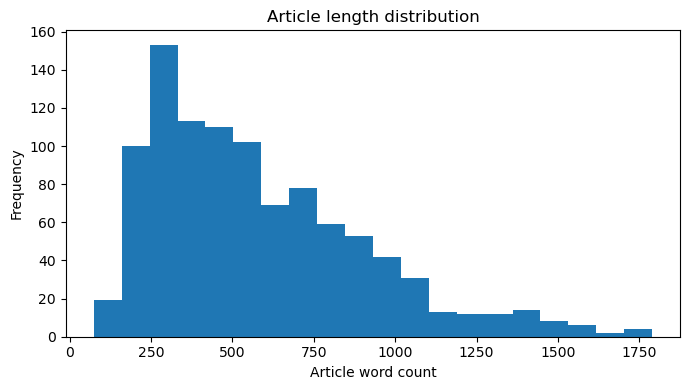

*Fact-density snapshot skipped because `outputs/cache/test_preprocess_summary.csv` is not available.*

In [3]:
TEST_PATH = DATA / 'test.csv'
PREPROC_PATH = CACHE / 'test_preprocess_summary.csv'
COMBINED_PATH = OUTPUTS / 'test_all_systems_combined.csv'
S0_PATH = OUTPUTS / 'system_runs' / 'test_S0.csv'

MAX_DOCS = 2000        # keep notebook lightweight
EDA_SAMPLE = 1000      # plot/sample size for compact EDA

def _normalize_text_series(s: pd.Series) -> pd.Series:
    return s.fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

def _word_count_series(s: pd.Series) -> pd.Series:
    return _normalize_text_series(s).str.findall(
        r"[A-Za-z]+(?:[-'][A-Za-z]+)?|\d+(?:,\d+)*(?:\.\d+)?"
    ).str.len()

def _sentence_count_series(s: pd.Series) -> pd.Series:
    txt = _normalize_text_series(s)
    counts = txt.str.count(r'[.!?]+')
    counts = counts.where(txt.eq(''), counts.clip(lower=1))
    counts = counts.where(~txt.ne(''), 0)
    return counts.astype(int)

def _load_eda_source():
    source_name = None
    df = None

    if TEST_PATH.exists():
        df = pd.read_csv(TEST_PATH, nrows=MAX_DOCS, low_memory=False)
        source_name = 'data/test.csv'
    elif S0_PATH.exists():
        df = pd.read_csv(S0_PATH, nrows=MAX_DOCS, low_memory=False)
        source_name = 'outputs/system_runs/test_S0.csv'
    elif COMBINED_PATH.exists():
        df = pd.read_csv(COMBINED_PATH, low_memory=False)
        source_name = 'outputs/test_all_systems_combined.csv'
    else:
        return None, None

    if 'highlights' in df.columns and 'reference' not in df.columns:
        df = df.rename(columns={'highlights': 'reference'})

    if {'doc_id', 'article', 'reference'}.issubset(df.columns):
        df = df[['doc_id', 'article', 'reference']].drop_duplicates(subset=['doc_id']).copy()
    elif {'article', 'reference'}.issubset(df.columns):
        df = df[['article', 'reference']].copy()
    else:
        return df, source_name

    if MAX_DOCS is not None:
        df = df.head(MAX_DOCS).copy()

    return df, source_name

eda_df, eda_source = _load_eda_source()

if eda_df is None:
    display(Markdown(
        '**Essential EDA unavailable.** Need one of `data/test.csv`, '
        '`outputs/system_runs/test_S0.csv`, or `outputs/test_all_systems_combined.csv`.'
    ))
else:
    eda = eda_df[['article', 'reference']].copy()
    if len(eda) > EDA_SAMPLE:
        eda = eda.sample(EDA_SAMPLE, random_state=42).reset_index(drop=True)

    eda['article_word_count'] = _word_count_series(eda['article'])
    eda['article_sentence_count'] = _sentence_count_series(eda['article'])
    eda['reference_word_count'] = _word_count_series(eda['reference'])
    eda['compression_ratio'] = eda['reference_word_count'] / eda['article_word_count'].replace(0, np.nan)

    eda_summary = pd.DataFrame({
        'metric': [
            'num documents in run',
            'num documents in eda',
            'avg article words',
            'median article words',
            'avg article sentences',
            'avg reference words',
            'median reference words',
            'avg compression ratio',
            'median compression ratio',
        ],
        'value': [
            len(eda_df),
            len(eda),
            round(eda['article_word_count'].mean(), 3),
            round(eda['article_word_count'].median(), 3),
            round(eda['article_sentence_count'].mean(), 3),
            round(eda['reference_word_count'].mean(), 3),
            round(eda['reference_word_count'].median(), 3),
            round(eda['compression_ratio'].mean(), 3),
            round(eda['compression_ratio'].median(), 3),
        ],
    })

    display(Markdown(
        f'**Length snapshot** (source: `{eda_source}`, using up to {len(eda_df):,} docs; '
        f'EDA table/plot built from {len(eda):,} sampled docs)'
    ))
    display(eda_summary)

    plt.figure(figsize=(7, 4))
    plt.hist(eda['article_word_count'], bins=min(20, max(5, len(eda))))
    plt.xlabel('Article word count')
    plt.ylabel('Frequency')
    plt.title('Article length distribution')
    plt.tight_layout()
    try:
        FIGURES.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES / 'eda_article_length_distribution.png', dpi=180)
    except Exception:
        pass
    plt.show()

if PREPROC_PATH.exists():
    pre_df = pd.read_csv(PREPROC_PATH)
    fact_summary = pd.DataFrame({
        'metric': [
            'rows in preprocess summary',
            'avg article sentences',
            'median article sentences',
            'avg entities/article',
            'avg numbers/article',
            'avg dates/article',
        ],
        'value': [
            len(pre_df),
            round(pre_df['n_sentences'].mean(), 2),
            round(pre_df['n_sentences'].median(), 2),
            round(pre_df['n_entities'].mean(), 2),
            round(pre_df['n_numbers'].mean(), 2),
            round(pre_df['n_dates'].mean(), 2),
        ],
    })
    display(Markdown('**Fact-density snapshot** (from `outputs/cache/test_preprocess_summary.csv`)'))
    display(fact_summary)
else:
    display(Markdown(
        '*Fact-density snapshot skipped because `outputs/cache/test_preprocess_summary.csv` is not available.*'
    ))


In [4]:
effect_path = TABLES / 'test_metric_summary_refactored.csv'
if effect_path.exists():
    effect_df = pd.read_csv(effect_path)

    cols = [c for c in [
        'system', 'rougel', 'flesch_reading_ease', 'fkgl',
        'entity_f1', 'number_f1', 'date_f1'
    ] if c in effect_df.columns]
    effect_df = effect_df[cols].copy()

    if {'entity_f1', 'number_f1', 'date_f1'}.issubset(effect_df.columns):
        effect_df['fact_f1_mean'] = effect_df[['entity_f1', 'number_f1', 'date_f1']].mean(axis=1)

    effect_df = effect_df.set_index('system')

    comparisons = []
    comparison_specs = [
        ('S0', 'S2', 'better sentence selection'),
        ('S2', 'S3', 'conservative simplification'),
        ('S2', 'S4', 'guarded rewrite'),
        ('S5', 'S6', 'DPO over SFT'),
    ]

    for base, new, note in comparison_specs:
        if base in effect_df.index and new in effect_df.index:
            row = {
                'comparison': f'{new} vs {base}',
                'design_choice': note,
            }
            if 'rougel' in effect_df.columns:
                row['ΔROUGE-L'] = effect_df.loc[new, 'rougel'] - effect_df.loc[base, 'rougel']
            if 'fact_f1_mean' in effect_df.columns:
                row['ΔFact-F1'] = effect_df.loc[new, 'fact_f1_mean'] - effect_df.loc[base, 'fact_f1_mean']
            if 'flesch_reading_ease' in effect_df.columns:
                row['ΔFRE'] = effect_df.loc[new, 'flesch_reading_ease'] - effect_df.loc[base, 'flesch_reading_ease']
            if 'fkgl' in effect_df.columns:
                row['ΔFKGL'] = effect_df.loc[new, 'fkgl'] - effect_df.loc[base, 'fkgl']
            comparisons.append(row)

    if comparisons:
        display(Markdown(
            '**Compact design-effect snapshot.**  '
            'Positive **ΔROUGE-L**, **ΔFact-F1**, and **ΔFRE** are better.  '
            'Negative **ΔFKGL** means the output became easier to read.'
        ))
        display(pd.DataFrame(comparisons).round(4))
    else:
        display(Markdown('**No design-effect comparisons available yet.** Build `test_metric_summary_refactored.csv` first.'))
else:
    display(Markdown('**Missing:** `outputs/tables/test_metric_summary_refactored.csv`'))


**Compact design-effect snapshot.**  Positive **ΔROUGE-L**, **ΔFact-F1**, and **ΔFRE** are better.  Negative **ΔFKGL** means the output became easier to read.

,comparison,design_choice,ΔROUGE-L,ΔFact-F1,ΔFRE,ΔFKGL
0,S2 vs S0,better sentence selection,-0.0164,0.1991,-0.9870,0.4077
1,S3 vs S2,conservative simplification,-0.0003,-0.0000,0.1389,-0.0174
2,S4 vs S2,guarded rewrite,-0.0090,0.0850,2.1269,-0.7413
3,S6 vs S5,DPO over SFT,-0.0070,0.0249,-0.5876,0.3187


## 2. Main metric summary

In [5]:
summary_path = TABLES / 'test_metric_summary_refactored.csv'
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df)
else:
    display(Markdown('**Missing:** `outputs/tables/test_metric_summary_refactored.csv`'))

,system,rouge1,rouge2,rougel,flesch_reading_ease,fkgl,entity_coverage,entity_precision,entity_f1,number_coverage,...,number_unsupported_ratio,date_unsupported_ratio,copy_token_ratio,novel_token_ratio,novel_content_token_ratio,word_count,sentence_count,avg_sentence_len,fact_f1_mean,unsupported_mean
0,S0,0.379854,0.164643,0.241837,48.907397,12.793759,0.199551,0.999304,0.316750,0.268009,...,0.000000,0.000000,1.000000,0.000000,0.000000,76.752654,2.999913,25.585016,0.381297,0.000000
1,S1,0.327936,0.128873,0.218790,50.014943,12.426432,0.194597,0.996432,0.311819,0.208229,...,0.000000,0.000000,1.000000,0.000000,0.000000,74.182332,2.999913,24.728242,0.351409,0.000000
2,S2,0.347218,0.140703,0.225429,47.920361,13.201465,0.239203,0.999913,0.371427,0.457267,...,0.000000,0.000000,1.000000,0.000000,0.000000,80.013577,2.999913,26.671990,0.580352,0.000000
3,S3,0.346802,0.140246,0.225158,48.059296,13.184094,0.239170,0.999891,0.371381,0.457267,...,0.000000,0.000000,0.998195,0.001805,0.002624,80.014534,2.999304,26.680070,0.580337,0.000007
4,S4,0.330398,0.141751,0.216396,50.047309,12.460157,0.309793,0.988287,0.452861,0.567376,...,0.000468,0.000000,0.997560,0.002440,0.003723,115.978329,4.602698,24.882169,0.665355,0.004060
5,S5,0.422453,0.201056,0.296617,56.591123,9.811727,0.166928,0.868043,0.269475,0.309061,...,0.010860,0.005360,0.983794,0.016206,0.023313,64.231767,3.720191,17.895436,0.391879,0.049334
6,S6,0.418635,0.199748,0.289657,56.003542,10.130414,0.183908,0.865679,0.291990,0.336745,...,0.011926,0.006448,0.982576,0.017424,0.025393,77.804439,4.228372,18.848350,0.416777,0.050811


## 3. Compact main-results table

In [6]:
compact_path = TABLES / 'test_main_results_compact.csv'
if compact_path.exists():
    compact_df = pd.read_csv(compact_path)
    display(compact_df)
else:
    display(Markdown('**Missing:** `outputs/tables/test_main_results_compact.csv`'))

,system,rougel,flesch_reading_ease,fkgl,fact_f1_mean,unsupported_mean,word_count
0,S0,0.241837,48.907397,12.793759,0.381297,0.000000,76.752654
1,S1,0.218790,50.014943,12.426432,0.351409,0.000000,74.182332
2,S2,0.225429,47.920361,13.201465,0.580352,0.000000,80.013577
3,S3,0.225158,48.059296,13.184094,0.580337,0.000007,80.014534
4,S4,0.216396,50.047309,12.460157,0.665355,0.004060,115.978329
5,S5,0.296617,56.591123,9.811727,0.391879,0.049334,64.231767
6,S6,0.289657,56.003542,10.130414,0.416777,0.050811,77.804439


## 4. Document counts by system

In [7]:
counts_path = TABLES / 'test_doc_counts_refactored.csv'
if counts_path.exists():
    counts_df = pd.read_csv(counts_path)
    display(counts_df)
else:
    display(Markdown('**Missing:** `outputs/tables/test_doc_counts_refactored.csv`'))

,system,n_docs
0,S0,11490
1,S1,11490
2,S2,11490
3,S3,11490
4,S4,11490
5,S5,11490
6,S6,11490


## 5. Generated plots

,figure
0,test_output_length_refactored.png
1,test_readability_faithfulness_bubble_refactore...
2,test_readability_vs_faithfulness_refactored.png
3,test_rougel_bar_refactored.png
4,test_rougel_bootstrap_ci_refactored.png
5,test_s3_effect_summary_refactored.png
6,test_s4_guard_behaviour_refactored.png
7,test_s4_selector_sweep_heatmap_refactored.png
8,test_unsupported_mean_refactored.png


### test_output_length_refactored.png

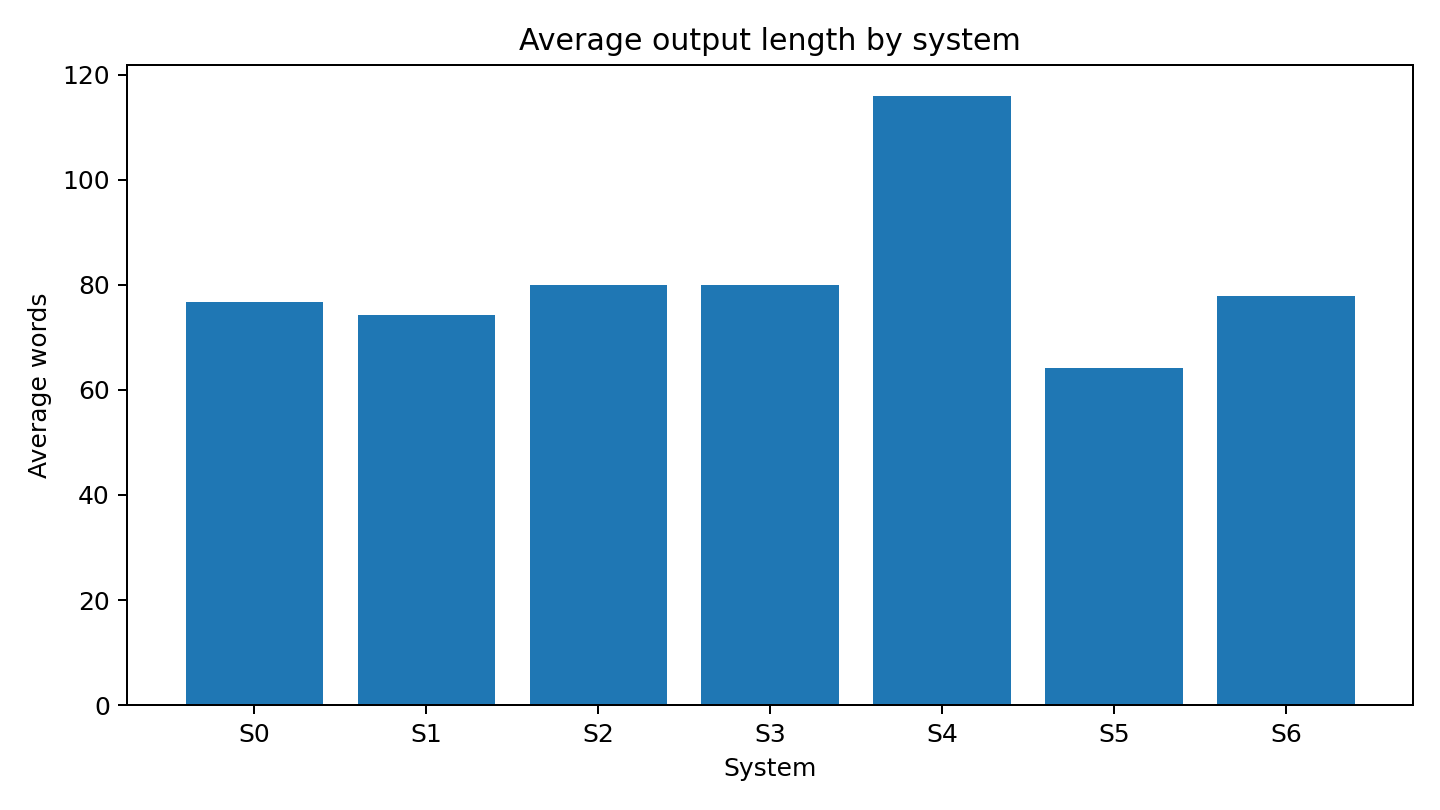

### test_readability_faithfulness_bubble_refactored.png

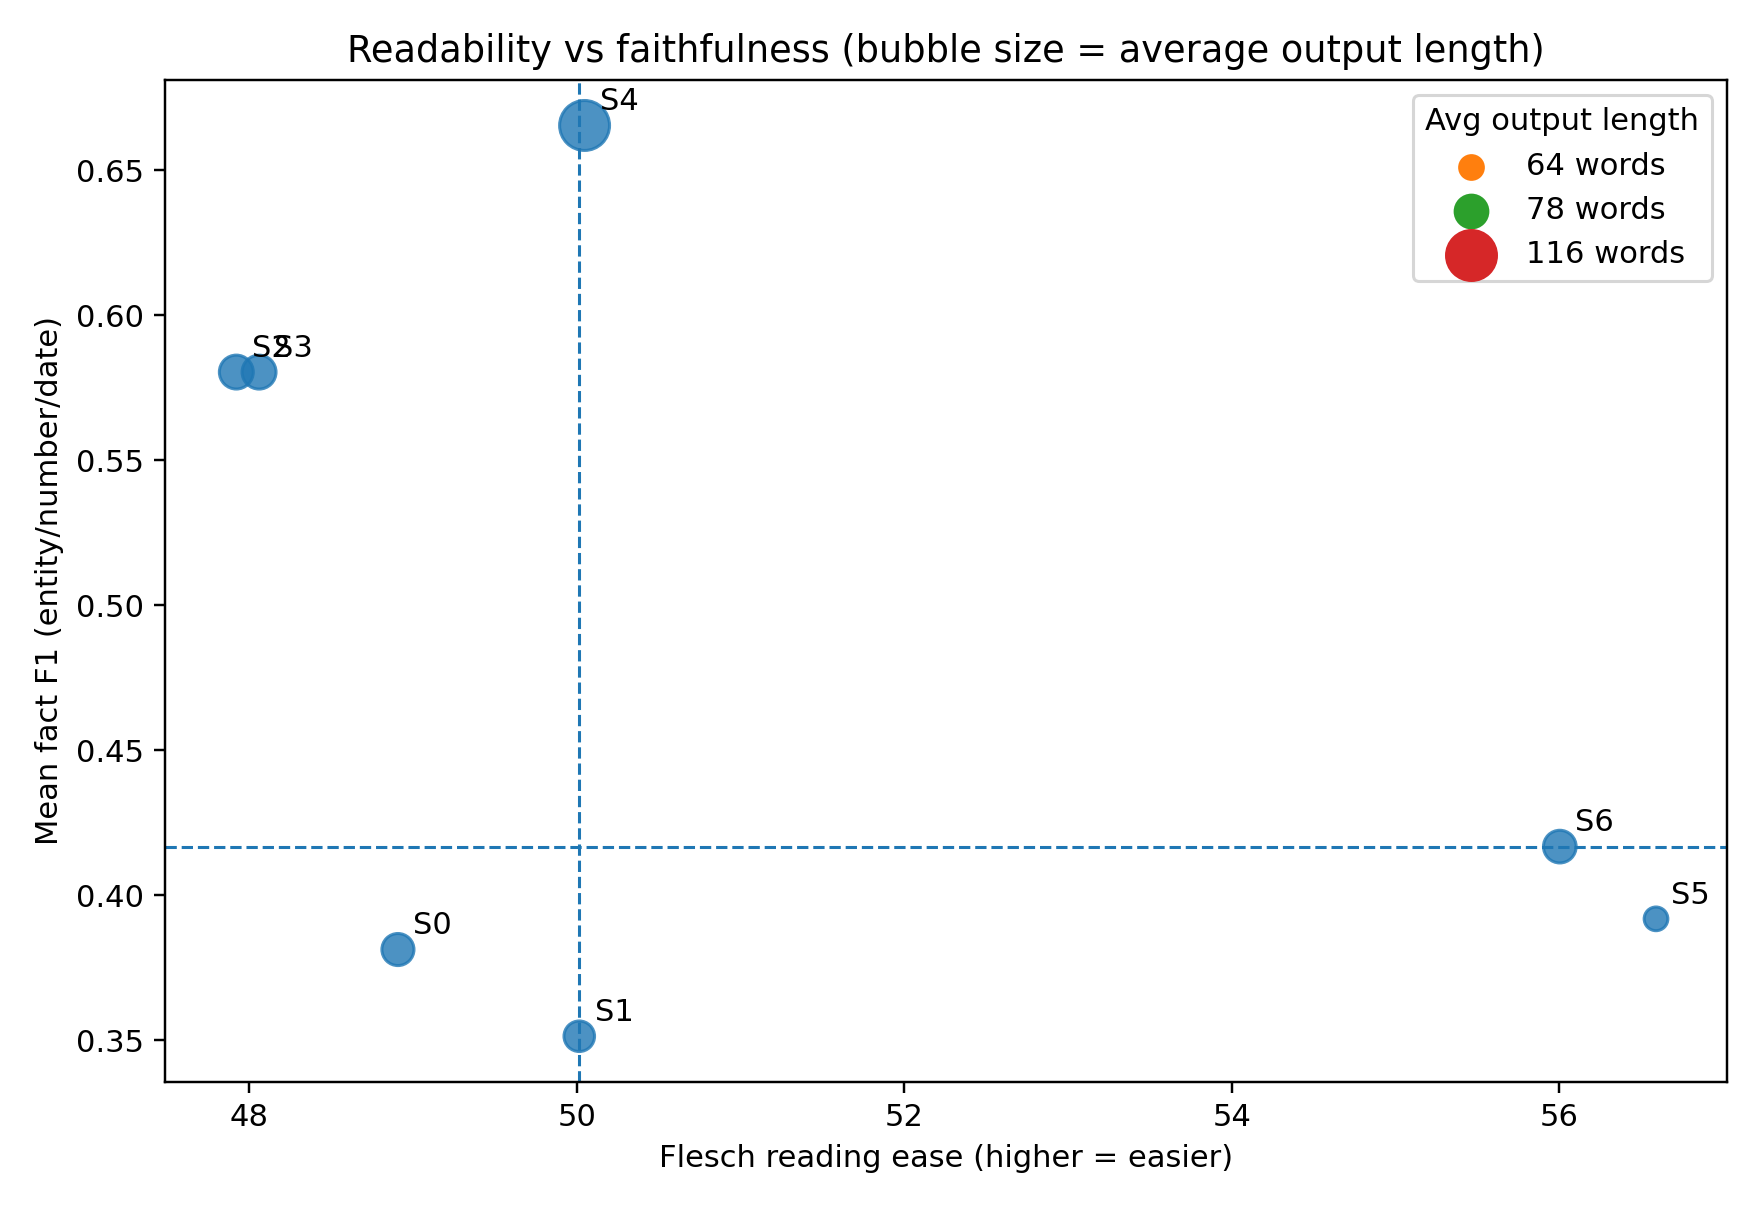

### test_readability_vs_faithfulness_refactored.png

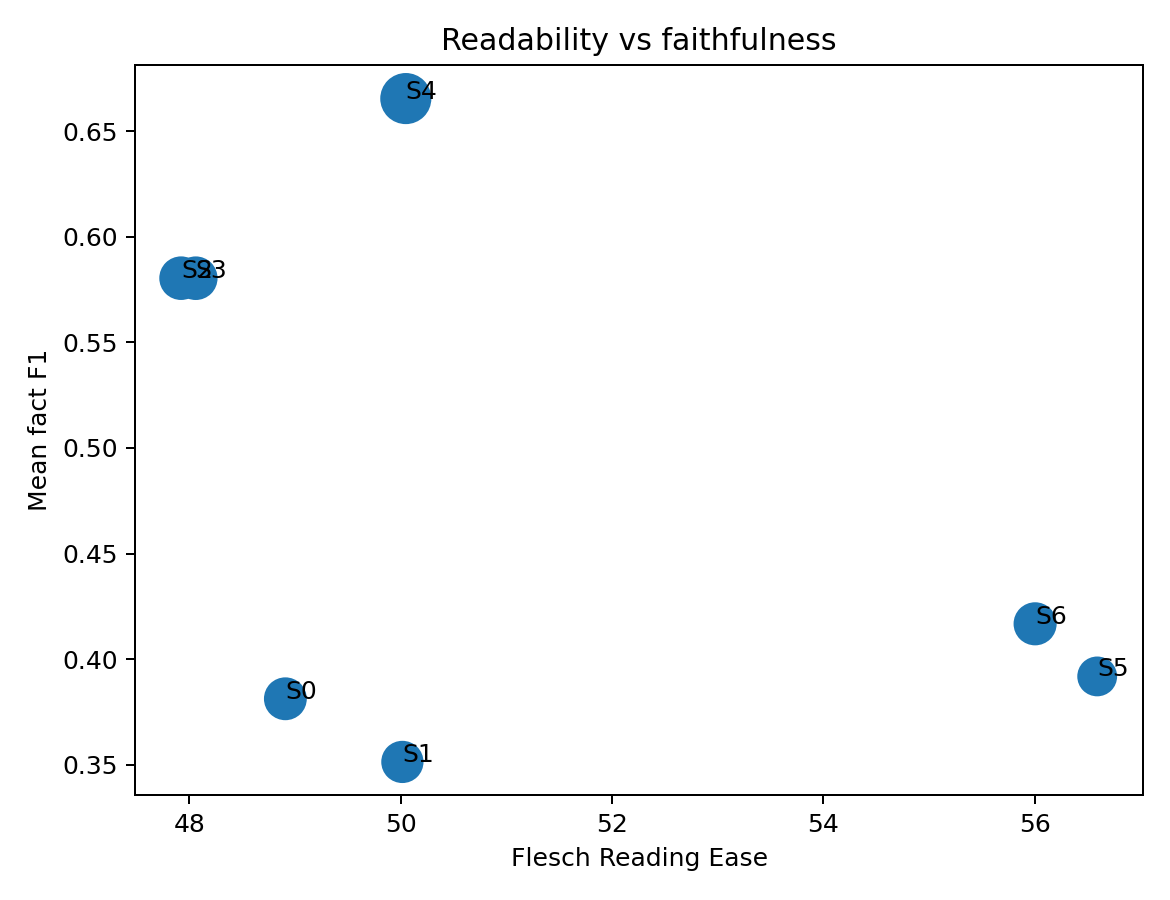

### test_rougel_bar_refactored.png

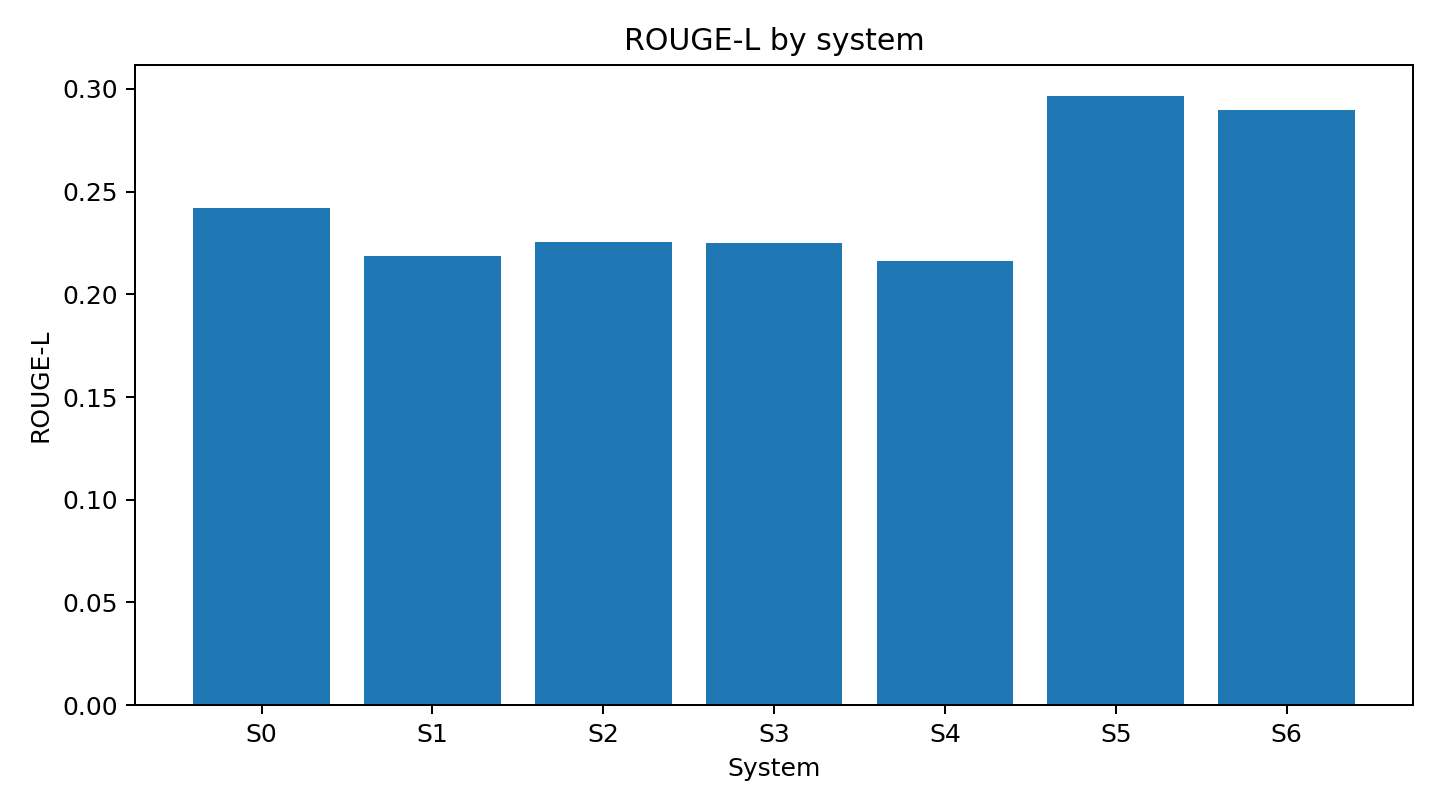

### test_rougel_bootstrap_ci_refactored.png

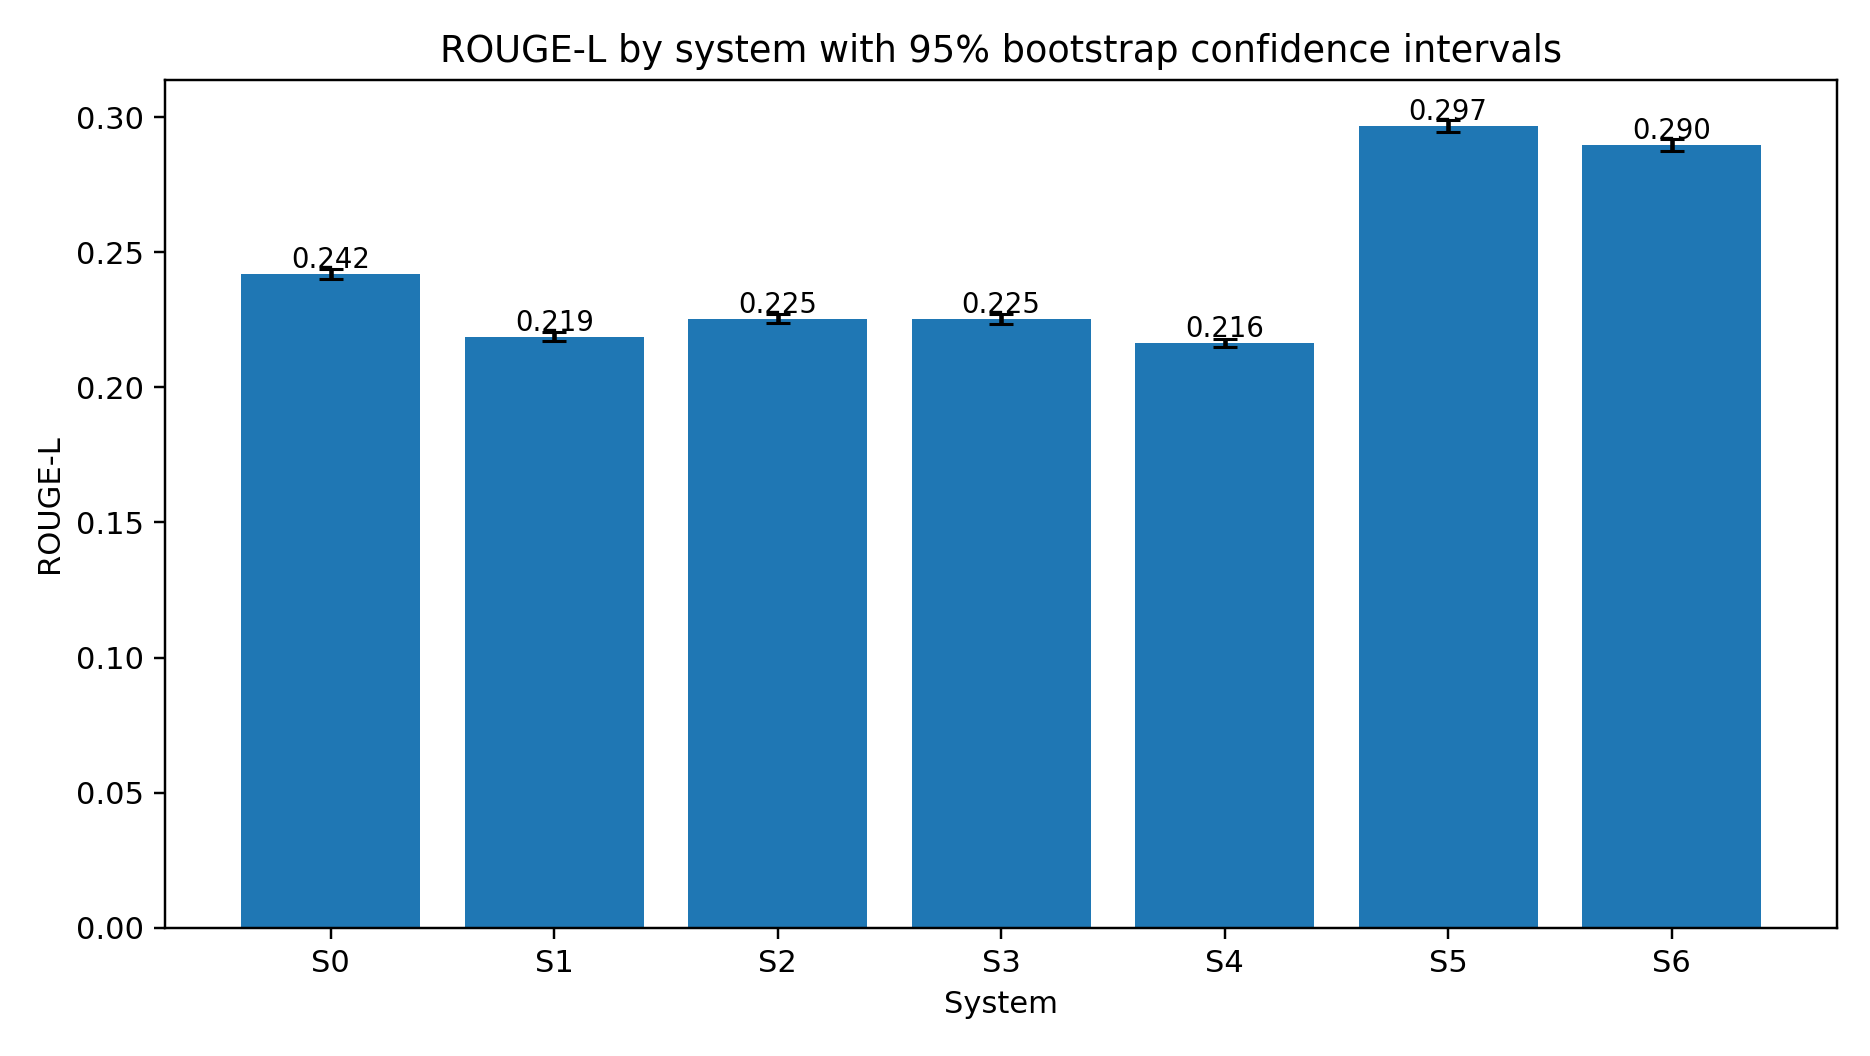

### test_s3_effect_summary_refactored.png

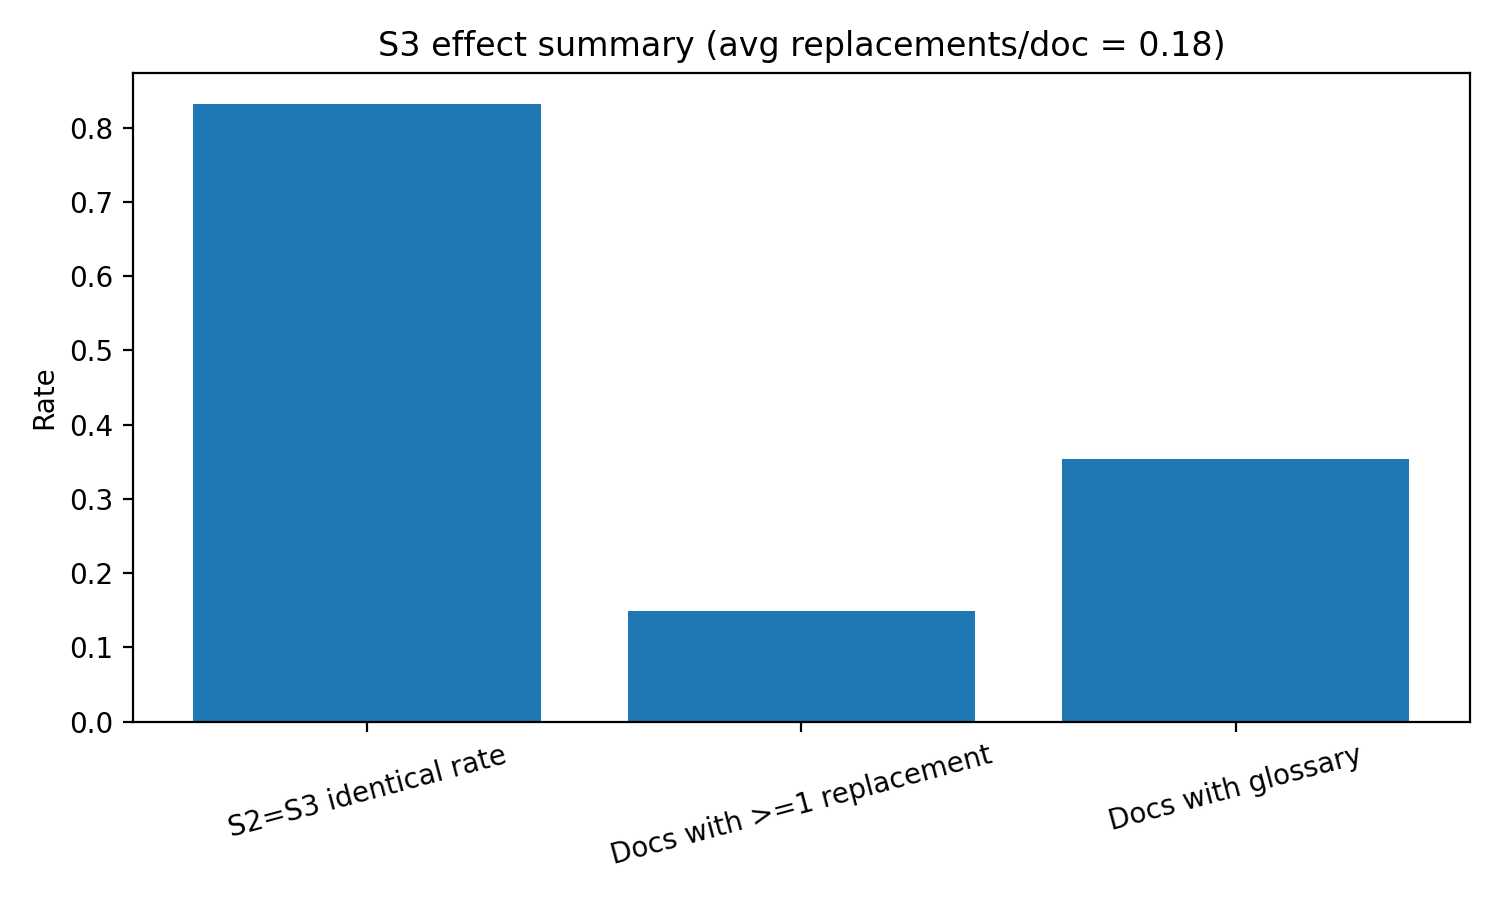

### test_s4_guard_behaviour_refactored.png

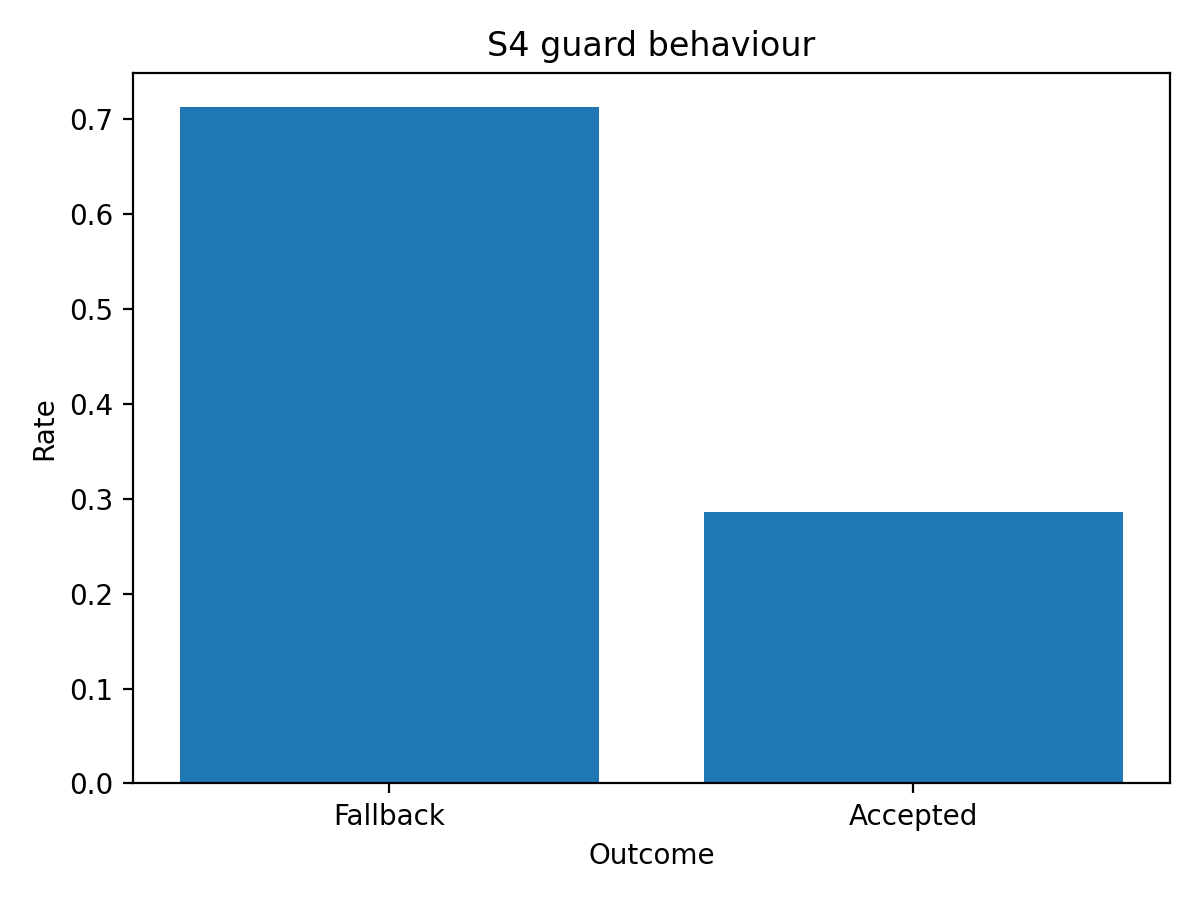

### test_s4_selector_sweep_heatmap_refactored.png

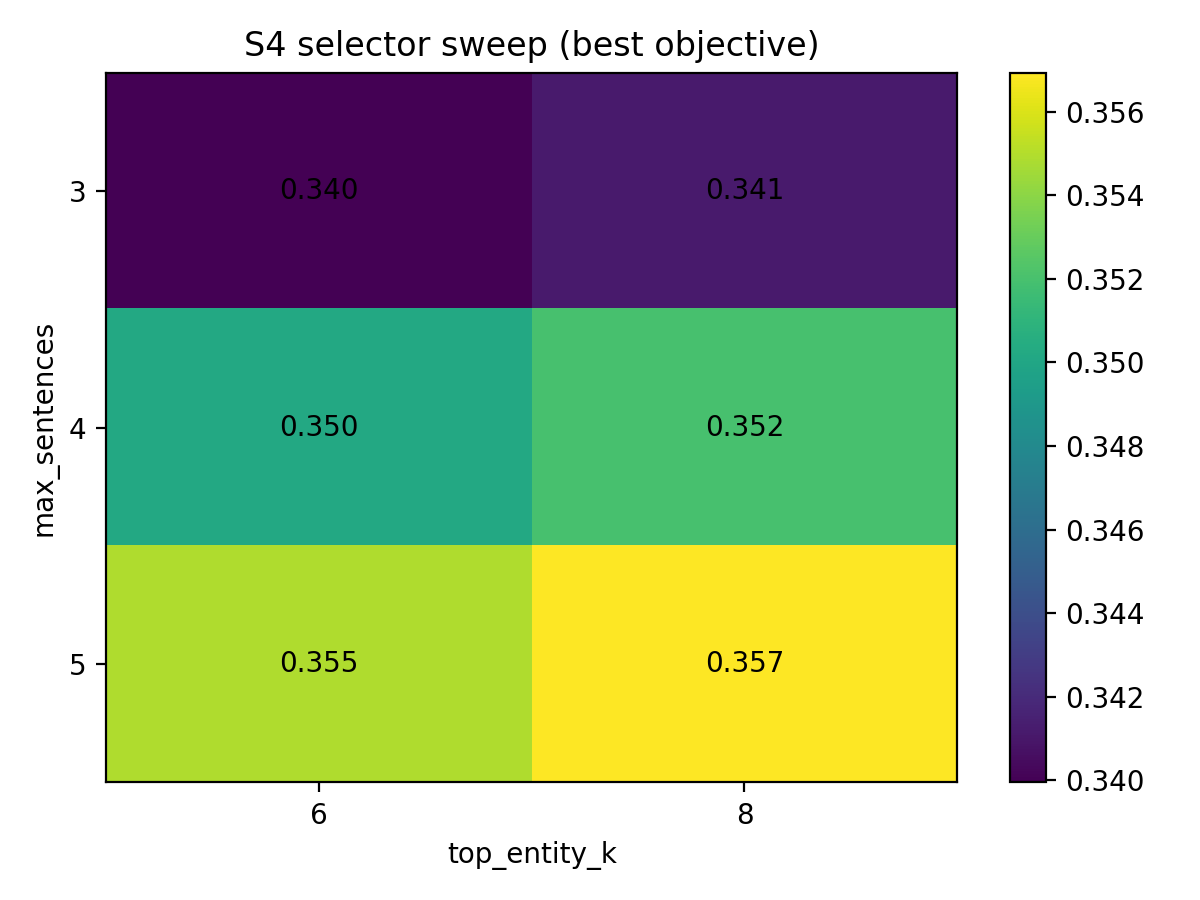

### test_unsupported_mean_refactored.png

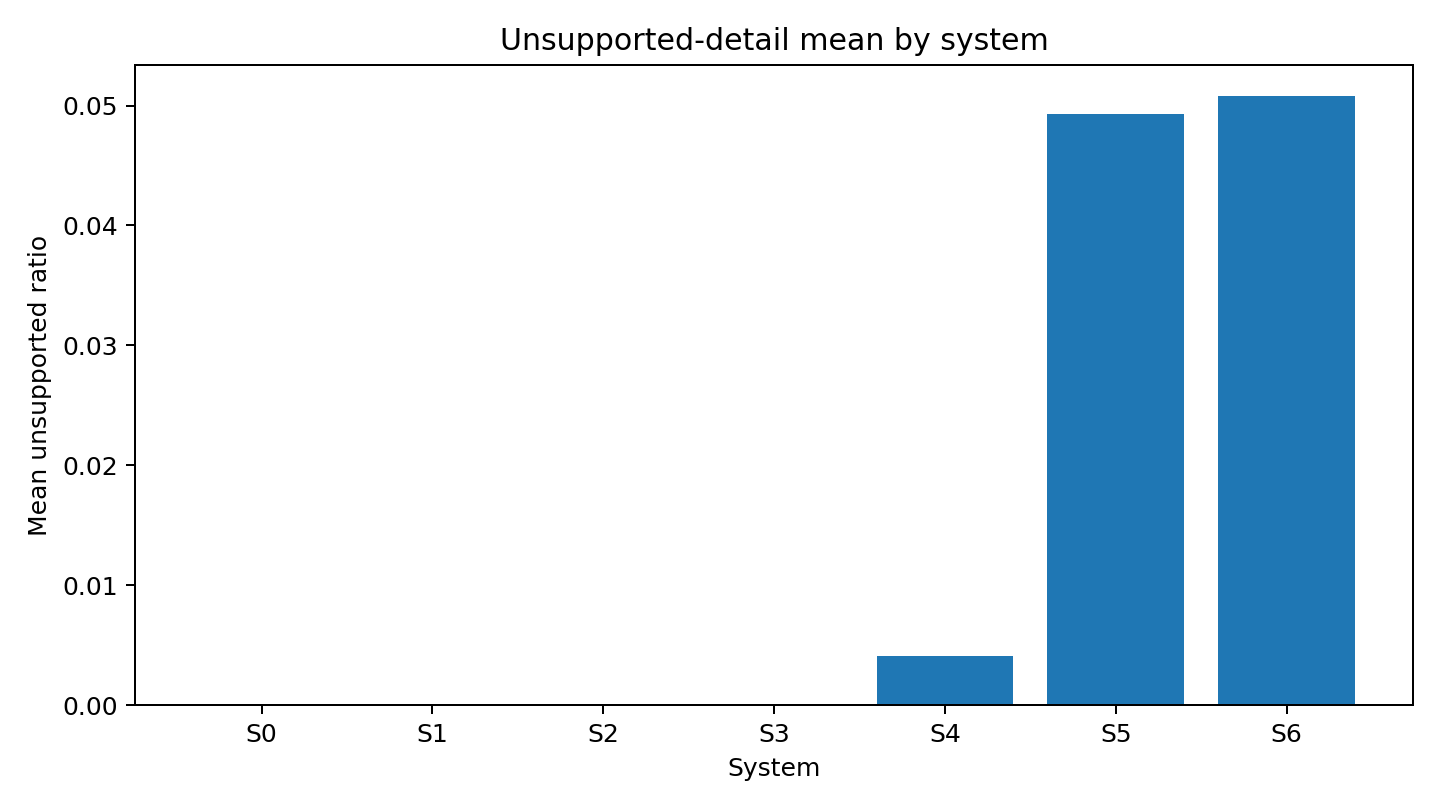

In [8]:
manifest_path = FIGURES / 'test_figure_manifest.csv'
if manifest_path.exists():
    manifest_df = pd.read_csv(manifest_path)
    display(manifest_df)
    for name in manifest_df['figure'].tolist():
        fig_path = FIGURES / name
        if fig_path.exists():
            display(Markdown(f'### {name}'))
            display(Image(filename=str(fig_path)))
else:
    fallback = sorted(FIGURES.glob('test_*_refactored.png'))
    if fallback:
        for fig_path in fallback:
            display(Markdown(f'### {fig_path.name}'))
            display(Image(filename=str(fig_path)))
    else:
        display(Markdown('**No plots found.** Run `make plots` first.'))

## 6. Optional preview of the combined S0–S6 output file

In [9]:
combined_path = OUTPUTS / 'test_all_systems_combined.csv'
if combined_path.exists():
    combined_preview = pd.read_csv(combined_path, nrows=20, low_memory=False)
    display(combined_preview.head(20))
else:
    display(Markdown('**Missing:** `outputs/test_all_systems_combined.csv`'))

,doc_id,id,system,article,reference,output,system_label,title,replacements,glossary,...,s4_src_dates_count,s4_raw_word_count,s4_entity_f1,s4_number_f1,s4_date_f1,s4_entity_unsupported_ratio,s4_number_unsupported_ratio,s4_date_unsupported_ratio,s5_mode,s5_num_chunks
0,0,0,S0,(CNN)The Palestinian Authority officially beca...,Membership gives the ICC jurisdiction over all...,(CNN)The Palestinian Authority officially beca...,S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,S0,(CNN)Never mind cats having nine lives. A stra...,"Theia, a bully breed mix, was apparently hit b...",(CNN)Never mind cats having nine lives. A stra...,S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2,S0,"(CNN)If you've been following the news lately,...",Mohammad Javad Zarif has spent more time with ...,"(CNN)If you've been following the news lately,...",S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3,S0,(CNN)Five Americans who were monitored for thr...,17 Americans were exposed to the Ebola virus w...,(CNN)Five Americans who were monitored for thr...,S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,4,S0,(CNN)A Duke student has admitted to hanging a ...,Student is no longer on Duke University campus...,(CNN)A Duke student has admitted to hanging a ...,S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,5,S0,(CNN)He's a blue chip college basketball recru...,College-bound basketball star asks girl with D...,(CNN)He's a blue chip college basketball recru...,S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,6,S0,(CNN)Governments around the world are using th...,Amnesty's annual death penalty report catalogs...,(CNN)Governments around the world are using th...,S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,7,S0,"(CNN)Andrew Getty, one of the heirs to billion...",Andrew Getty's death appears to be from natura...,"(CNN)Andrew Getty, one of the heirs to billion...",S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,8,S0,(CNN)Filipinos are being warned to be on guard...,"Once a super typhoon, Maysak is now a tropical...",(CNN)Filipinos are being warned to be on guard...,S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,9,S0,"(CNN)For the first time in eight years, a TV l...","Bob Barker returned to host ""The Price Is Righ...","(CNN)For the first time in eight years, a TV l...",S0 Lead-3,NaN,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
